# MSD verification on SuSuInterActs

This notebook verifies the `motion_generation/utils/msd` module against the paper **Not All Frames Are Equal: Complexity-Aware Masked Motion Generation via Motion Spectral Descriptors** and the WS1 acceptance checks.

Paper recipe, adapted to SentiAvatar RVQ tokens:

1. Convert one motion-token frame `(res1, res2, res3, res4)` into a continuous frame embedding by summing the four frozen RVQ codebook vectors.
2. Compute velocity `v_t = x_t - x_{t-1}`, with the first velocity copied from the second.
3. Extract a centered sliding window of length `W` and apply Type-II DCT along time for every feature dimension.
4. L2 aggregate DCT coefficients across feature dimensions into per-band energy.
5. L2-normalize the band vector to get `phi_t`, then compute `Omega(t) = mean(phi_t)`.

Important project note: the current RVQVAE checkpoint has `unit_length=2`, so raw SuSu motion is 20fps but RVQ token frames are effectively 10fps. The notebook logs the effective time span of the selected windows and keeps the window size tunable.

## Run Mode

Use the `sentiavatar` conda environment as the notebook kernel if possible:

```text
C:/Users/WenJChai/miniconda3/envs/sentiavatar/python.exe
```

The defaults are intentionally small and safe. Flip `RUN_AGREEMENT_500` and `RUN_FULL_CACHE` only after the quick checks pass.

In [11]:
from pathlib import Path
import json
import math
import random
import sys
import time
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.fft import dct as scipy_dct
from scipy.stats import spearmanr

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

torch.set_grad_enabled(False)
plt.rcParams["figure.dpi"] = 120

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "motion_generation").exists() and (path / "checkpoints").exists():
            return path
    raise RuntimeError("Could not find project root containing motion_generation/ and checkpoints/.")

PROJECT_ROOT = find_project_root()
MOTION_DIR = PROJECT_ROOT / "motion_generation"
MSD_DIR = MOTION_DIR / "utils" / "msd"
sys.path.insert(0, str(MOTION_DIR))
sys.path.insert(0, str(MSD_DIR))

from msd import (
    MSDConfig,
    compute_msd,
    dct2_matrix,
    msd_from_tokens,
    msd_from_motion,
    omega_to_weights,
    pool_motion_omega_to_token_rate,
)
from scripts.train_audio_fim_causal import (
    body_features_to_quat_motion,
    decode_body_tokens_to_features,
    load_rvqvae_model_for_eval,
)
from utils.constants import BODY_JOINTS_ID
from utils.fk_model import WorldPosFromQuat

print("project:", PROJECT_ROOT)
print("msd dir:", MSD_DIR)

project: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox
msd dir: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd


In [12]:
# Paths.
DATASET_ROOT = PROJECT_ROOT / "SuSuInterActs" / "SuSuInterActs"
MOTION_TOKEN_DIR = DATASET_ROOT / "motion_token_data"
RVQVAE_CKPT = PROJECT_ROOT / "checkpoints" / "rvqvae" / "model" / "epoch_30.pth"
RVQVAE_MEAN = MOTION_DIR / "meta" / "mta_gen_demo" / "mean.npy"
RVQVAE_STD = MOTION_DIR / "meta" / "mta_gen_demo" / "std.npy"
TEXT_JSON = DATASET_ROOT / "text_data" / "motion2text.json"
TEMPLATE_BVH = MOTION_DIR / "meta" / "template_susu_retarget_63nodes.bvh"

# Window policy.
RAW_MOTION_FPS = 20.0
RVQVAE_UNIT_LENGTH = 2.0
TOKEN_FPS = RAW_MOTION_FPS / RVQVAE_UNIT_LENGTH

# Current module default: W=8 at token rate, matched by W=16 at decoded 20fps.
# If you want a strict 0.4s window at token rate, set W_TOKEN=4 and W_MOTION=8.
W_TOKEN = 8
W_MOTION = int(round(W_TOKEN * RVQVAE_UNIT_LENGTH))

# Strict WS1.2 reference: decode GT tokens -> FK body-joint positions -> MSD velocity pipeline.
# Set to "body_features" for the cheaper decoded-feature proxy.
DECODED_MSD_REFERENCE = "joint_positions"

# Verification sizes.
SPLIT_FOR_QUICK_CHECKS = "val"
DECODED_VARIANT_N = 10
AGREEMENT_N_QUICK = 50
AGREEMENT_N_GATE = 500
RUN_AGREEMENT_500 = False
VISUAL_N = 10

# Cache settings. Keep full cache off until token JSON exists and quick checks pass.
RUN_FULL_CACHE = False
CACHE_LIMIT_PER_SPLIT = 10
CACHE_SPEEDS = [1.0]
# When full-cacheing a training speed augmentation, switch to [0.9, 1.0, 1.1]
# only if nearest-neighbor token resampling matches your dataloader convention.

OUTPUT_DIR = MSD_DIR / "outputs" / "verify_msd_susuinteracts"
CACHE_DIR = MSD_DIR / "outputs" / "cache_token_msd"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("dataset root:", DATASET_ROOT, DATASET_ROOT.exists())
print("motion_token_data:", MOTION_TOKEN_DIR, MOTION_TOKEN_DIR.exists())
print("rvqvae checkpoint:", RVQVAE_CKPT, RVQVAE_CKPT.exists())
print(f"token fps: {TOKEN_FPS:g}; W_TOKEN={W_TOKEN} => {W_TOKEN / TOKEN_FPS:.3f}s")
print(f"decoded fps: {RAW_MOTION_FPS:g}; W_MOTION={W_MOTION} => {W_MOTION / RAW_MOTION_FPS:.3f}s")
if abs(W_TOKEN / TOKEN_FPS - 0.4) > 1e-6:
    warnings.warn("W_TOKEN=8 spans 0.8s for the current 10fps RVQ tokens. Set W_TOKEN=4 for a 0.4s token-rate window.")

dataset root: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\SuSuInterActs\SuSuInterActs True
motion_token_data: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\SuSuInterActs\SuSuInterActs\motion_token_data False
rvqvae checkpoint: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\checkpoints\rvqvae\model\epoch_30.pth True
token fps: 10; W_TOKEN=8 => 0.800s
decoded fps: 20; W_MOTION=16 => 0.800s


C:\Users\WenJChai\AppData\Local\Temp\ipykernel_73296\2722501376.py:49: UserWarning: W_TOKEN=8 spans 0.8s for the current 10fps RVQ tokens. Set W_TOKEN=4 for a 0.4s token-rate window.
  warnings.warn("W_TOKEN=8 spans 0.8s for the current 10fps RVQ tokens. Set W_TOKEN=4 for a 0.4s token-rate window.")


## 1.1 Synthetic MSD Acceptance Checks

These are notebook versions of `test_msd.py`: constant pose should produce flat/near-zero `Omega`, and a sinusoidal velocity at DCT band `k` should peak in that band.

synthetic checks passed; constant max omega: 0.0


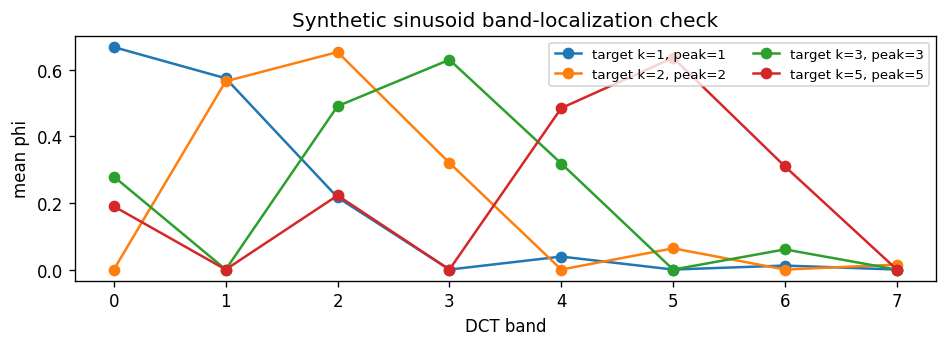

In [13]:
def run_synthetic_checks(T=120, D=32, W=8, fs=10.0):
    x_const = torch.ones(T, D) * 3.14
    _, omega_const = compute_msd(x_const, MSDConfig(W=W))
    const_max = float(omega_const.abs().max())
    assert const_max < 1e-3, f"constant pose omega too high: {const_max}"

    rows = []
    for k0 in [1, 2, 3, 5]:
        f_hz = k0 * fs / (2 * W)
        t = torch.arange(T, dtype=torch.float32)
        v = torch.zeros(T, D)
        v[:, 0] = torch.cos(2 * math.pi * f_hz * t / fs)
        x = torch.cumsum(v, dim=0)
        phi, _ = compute_msd(x, MSDConfig(W=W))
        spec = phi[W:-W].mean(dim=0)
        peak_band = 1 + spec[1:].argmax().item()
        rows.append((k0, f_hz, peak_band, spec.detach().cpu().numpy()))
        assert peak_band == k0, f"expected non-DC band {k0}, got {peak_band}"

    sig = np.random.RandomState(0).randn(W)
    ours = dct2_matrix(W) @ torch.tensor(sig, dtype=torch.float32)
    ref = scipy_dct(sig, type=2, norm=None) / 2.0
    assert torch.allclose(ours, torch.tensor(ref, dtype=torch.float32), atol=1e-4)
    print("synthetic checks passed; constant max omega:", const_max)
    return rows

synthetic_rows = run_synthetic_checks(W=W_TOKEN, fs=TOKEN_FPS)

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
for k0, f_hz, peak_band, spec in synthetic_rows:
    ax.plot(spec, marker="o", label=f"target k={k0}, peak={peak_band}")
ax.set_xlabel("DCT band")
ax.set_ylabel("mean phi")
ax.set_title("Synthetic sinusoid band-localization check")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## Load RVQVAE And Codebooks

This is the integration point for WS1.1. For this repo, the frozen RVQ codebooks are available as `rvqvae.quantizer_dict['body'].codebooks` with shape `(4, 512, 512)`.

In [14]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

rvqvae, rvq_config = load_rvqvae_model_for_eval(RVQVAE_CKPT, DEVICE)
rvqvae.eval()
mean = torch.tensor(np.load(RVQVAE_MEAN), dtype=torch.float32, device=DEVICE)
std = torch.tensor(np.load(RVQVAE_STD), dtype=torch.float32, device=DEVICE)
codebooks = rvqvae.quantizer_dict["body"].codebooks.detach().float().to(DEVICE)

assert tuple(codebooks.shape[:2]) == (4, 512), codebooks.shape
assert int(rvq_config.model.num_quantizers) == 4
assert int(rvq_config.model.nb_code) == 512
print("codebooks:", tuple(codebooks.shape))
print("rvq unit_length:", getattr(rvq_config, "unit_length", None), "raw fps:", rvq_config.data.fps)

device: cpu
codebooks: (4, 512, 512)
rvq unit_length: 2 raw fps: 20


## SuSuInterActs Helpers

If `motion_token_data` exists, the notebook uses those token JSON files. If not, it encodes raw `motion_data` through the RVQVAE for the requested verification subset. Full-cache mode should use precomputed token JSONs.

In [15]:
def read_split(split):
    path = DATASET_ROOT / "split" / f"{split}_file_list.txt"
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip().replace("\\", "/") for line in f if line.strip()]

def sample_path(root, subdir, name, suffix):
    return root / subdir / Path(*Path(name).parts).with_suffix(suffix)

def motion_path(name):
    return sample_path(DATASET_ROOT, "motion_data", name, ".npy")

def token_path(name):
    return sample_path(DATASET_ROOT, "motion_token_data", name, ".json")

def load_text_map():
    if not TEXT_JSON.exists():
        return {}
    with open(TEXT_JSON, "r", encoding="utf-8") as f:
        return json.load(f)

TEXT_MAP = load_text_map()

def valid_names(split, limit=None):
    names = []
    for name in read_split(split):
        if motion_path(name).exists():
            names.append(name)
        if limit is not None and len(names) >= limit:
            break
    return names

def load_motion_dict(name):
    data = np.load(motion_path(name), allow_pickle=True)
    if isinstance(data, np.ndarray) and data.dtype == object:
        data = data.item()
    if not isinstance(data, dict) or "body" not in data:
        raise ValueError(f"Unsupported motion data for {name}")
    return data

def preprocess_body_for_codec(motion_dict):
    body = torch.tensor(motion_dict["body"], dtype=torch.float32, device=DEVICE).clone()
    body[:, 2] = body[:, 2] - body[0, 2]
    body[1:, :3] = body[1:, :3] - body[:-1, :3]
    return ((body - mean) / std).unsqueeze(0)

def load_tokens_from_json(name):
    path = token_path(name)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    tokens = payload["tokens"] if isinstance(payload, dict) else payload
    return torch.tensor(tokens, dtype=torch.long, device=DEVICE)

def encode_tokens_from_raw_motion(name):
    motion = load_motion_dict(name)
    body_input = preprocess_body_for_codec(motion)
    encoded = rvqvae.encode(body_input)
    return encoded["code_idx"]["body"][0].long()

def get_tokens(name):
    tokens = load_tokens_from_json(name)
    if tokens is not None:
        return tokens, "json"
    return encode_tokens_from_raw_motion(name), "encoded_raw"

def decode_tokens_to_body(tokens):
    tokens_np = tokens.detach().cpu().numpy().astype(np.int64).tolist()
    return decode_body_tokens_to_features(rvqvae, tokens_np, mean, std, DEVICE)

FK_MODEL = None

def get_fk_model():
    global FK_MODEL
    if FK_MODEL is None:
        FK_MODEL = WorldPosFromQuat(template_bvh_path=str(TEMPLATE_BVH)).to(DEVICE).eval()
    return FK_MODEL

def decoded_body_to_body_joint_positions(name, body_decoded):
    motion = load_motion_dict(name)
    quat_motion = body_features_to_quat_motion(
        body_decoded,
        motion,
        DEVICE,
        src_fps=RAW_MOTION_FPS,
        tgt_fps=RAW_MOTION_FPS,
    )
    quat = torch.tensor(quat_motion["quat"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    offset = torch.tensor(quat_motion["offset"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    positions = get_fk_model()(quat, offset)[0]
    return positions[:, BODY_JOINTS_ID].reshape(positions.shape[0], -1)

def decoded_motion_reference_features(name, body_decoded):
    if DECODED_MSD_REFERENCE == "body_features":
        return body_decoded, "body_features"
    if DECODED_MSD_REFERENCE == "joint_positions":
        return decoded_body_to_body_joint_positions(name, body_decoded), "body_joint_positions"
    raise ValueError(f"Unknown DECODED_MSD_REFERENCE={DECODED_MSD_REFERENCE!r}")

def apply_speed_variant_tokens(tokens, speed):
    speed = float(speed)
    if abs(speed - 1.0) < 1e-6:
        return tokens
    new_T = max(2, int(round(tokens.shape[0] / speed)))
    idx = torch.linspace(0, tokens.shape[0] - 1, new_T, device=tokens.device).round().long()
    return tokens[idx]

names_quick = valid_names(SPLIT_FOR_QUICK_CHECKS, limit=max(DECODED_VARIANT_N, VISUAL_N, AGREEMENT_N_QUICK))
print("quick split:", SPLIT_FOR_QUICK_CHECKS, "names:", len(names_quick))
print("example:", names_quick[0] if names_quick else None)
if not MOTION_TOKEN_DIR.exists():
    print("motion_token_data is missing; this notebook will encode requested verification clips from raw motion.")

quick split: val names: 50
example: fbx_to_json_data_susu_retarget_maya/20250910/Human_0908_188-9_01
motion_token_data is missing; this notebook will encode requested verification clips from raw motion.


## 1.2 Decoded-Motion MSD Variant

Decode GT tokens through RVQVAE, project to the configured decoded reference, and confirm end-to-end shape/finite checks on 10 clips. The default `DECODED_MSD_REFERENCE="joint_positions"` computes FK body-joint positions, so `compute_msd` differentiates them into joint velocities before the DCT.

In [16]:
decoded_rows = []
for name in tqdm(names_quick[:DECODED_VARIANT_N], desc="decoded-motion MSD check"):
    tokens, source = get_tokens(name)
    body_decoded = decode_tokens_to_body(tokens)
    motion_ref, ref_name = decoded_motion_reference_features(name, body_decoded)
    phi_tok, omega_tok = msd_from_tokens(tokens, codebooks, MSDConfig(W=W_TOKEN))
    phi_mot, omega_mot = msd_from_motion(motion_ref, MSDConfig(W=W_MOTION, energy_floor=0.0))
    assert phi_tok.shape == (tokens.shape[0], W_TOKEN)
    assert phi_mot.shape == (motion_ref.shape[0], W_MOTION)
    assert torch.isfinite(phi_tok).all() and torch.isfinite(omega_tok).all()
    assert torch.isfinite(phi_mot).all() and torch.isfinite(omega_mot).all()
    decoded_rows.append({
        "clip": name,
        "source": source,
        "token_frames": int(tokens.shape[0]),
        "decoded_reference": ref_name,
        "decoded_frames": int(motion_ref.shape[0]),
        "decoded_dim": int(motion_ref.shape[1]),
        "omega_token_min": float(omega_tok.min().detach().cpu()),
        "omega_token_max": float(omega_tok.max().detach().cpu()),
        "omega_motion_min": float(omega_mot.min().detach().cpu()),
        "omega_motion_max": float(omega_mot.max().detach().cpu()),
    })

decoded_rows[:3], len(decoded_rows)

decoded-motion MSD check: 100%|██████████| 10/10 [00:00<00:00, 17.25it/s]


([{'clip': 'fbx_to_json_data_susu_retarget_maya/20250910/Human_0908_188-9_01',
   'source': 'encoded_raw',
   'token_frames': 70,
   'decoded_reference': 'body_joint_positions',
   'decoded_frames': 140,
   'decoded_dim': 75,
   'omega_token_min': 0.22653186321258545,
   'omega_token_max': 0.35265833139419556,
   'omega_motion_min': 0.1152724176645279,
   'omega_motion_max': 0.23946422338485718},
  {'clip': 'fbx_to_json_data_susu_retarget_maya/20250905/Human_0904_144-1_01',
   'source': 'encoded_raw',
   'token_frames': 69,
   'decoded_reference': 'body_joint_positions',
   'decoded_frames': 138,
   'decoded_dim': 75,
   'omega_token_min': 0.2787419557571411,
   'omega_token_max': 0.35116079449653625,
   'omega_motion_min': 0.1048865020275116,
   'omega_motion_max': 0.21787016093730927},
  {'clip': 'fbx_to_json_data_susu_retarget_maya/20251015/Human_0916_250_3_8_01',
   'source': 'encoded_raw',
   'token_frames': 41,
   'decoded_reference': 'body_joint_positions',
   'decoded_frames': 

## 1.3 Agreement Study

Compute per-clip Spearman rank correlation between token-embedding `Omega(t)` and decoded-reference `Omega(t)` pooled back to the token grid. WS1 gate: median correlation > 0.9 means token-level MSD is safe to use everywhere.

In [17]:
def compute_agreement(names, energy_floor=0.0):
    rows = []
    skipped = []
    for name in tqdm(names, desc="MSD agreement"):
        tokens, source = get_tokens(name)
        _, om_tok = msd_from_tokens(tokens, codebooks, MSDConfig(W=W_TOKEN))
        body_decoded = decode_tokens_to_body(tokens)
        motion_ref, ref_name = decoded_motion_reference_features(name, body_decoded)
        _, om_mot = msd_from_motion(motion_ref, MSDConfig(W=W_MOTION, energy_floor=energy_floor))
        om_mot_tok = pool_motion_omega_to_token_rate(om_mot.detach().cpu(), int(tokens.shape[0]))
        om_tok_cpu = om_tok.detach().cpu()[: om_mot_tok.shape[0]]
        if om_tok_cpu.std() < 1e-6 or om_mot_tok.std() < 1e-6:
            skipped.append(name)
            continue
        rho = spearmanr(om_tok_cpu.numpy(), om_mot_tok.numpy()).correlation
        rows.append({"clip": name, "source": source, "reference": ref_name, "spearman": float(rho), "T": int(om_tok_cpu.shape[0])})
    return rows, skipped

agreement_n = AGREEMENT_N_GATE if RUN_AGREEMENT_500 else AGREEMENT_N_QUICK
agreement_names = valid_names(SPLIT_FOR_QUICK_CHECKS, limit=agreement_n)
t0 = time.perf_counter()
agreement_rows, agreement_skipped = compute_agreement(agreement_names)
elapsed = time.perf_counter() - t0

rhos = np.array([r["spearman"] for r in agreement_rows], dtype=np.float32)
if len(rhos):
    print(f"scored={len(rhos)} skipped={len(agreement_skipped)} elapsed={elapsed:.1f}s")
    print(f"median={np.median(rhos):.4f} p10={np.percentile(rhos, 10):.4f} frac_gt_0.9={(rhos > 0.9).mean():.2%}")
    print("GATE:", "PASS use token-level MSD" if np.median(rhos) > 0.9 else "FAIL prefer decoded-motion MSD/precompute")
else:
    print("No non-degenerate clips scored.")

agreement_path = OUTPUT_DIR / f"agreement_{SPLIT_FOR_QUICK_CHECKS}_{len(agreement_rows)}.csv"
with open(agreement_path, "w", encoding="utf-8") as f:
    f.write("clip,source,reference,spearman,T\n")
    for row in agreement_rows:
        f.write(f"{row['clip']},{row['source']},{row['reference']},{row['spearman']:.6f},{row['T']}\n")
print("agreement csv:", agreement_path)

MSD agreement: 100%|██████████| 50/50 [00:03<00:00, 15.41it/s]

scored=50 skipped=0 elapsed=3.2s
median=-0.1459 p10=-0.3040 frac_gt_0.9=0.00%
GATE: FAIL prefer decoded-motion MSD/precompute
agreement csv: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\agreement_val_50.csv


## 1.4 Visual Sanity

The plots show token-level `phi_t` heatmaps, token and decoded-reference `Omega(t)`, and raw joint-position speed when available. High-Omega regions should visually line up with faster/jerkier gesture strokes rather than idle sections.

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250910__Human_0908_188-9_01.png


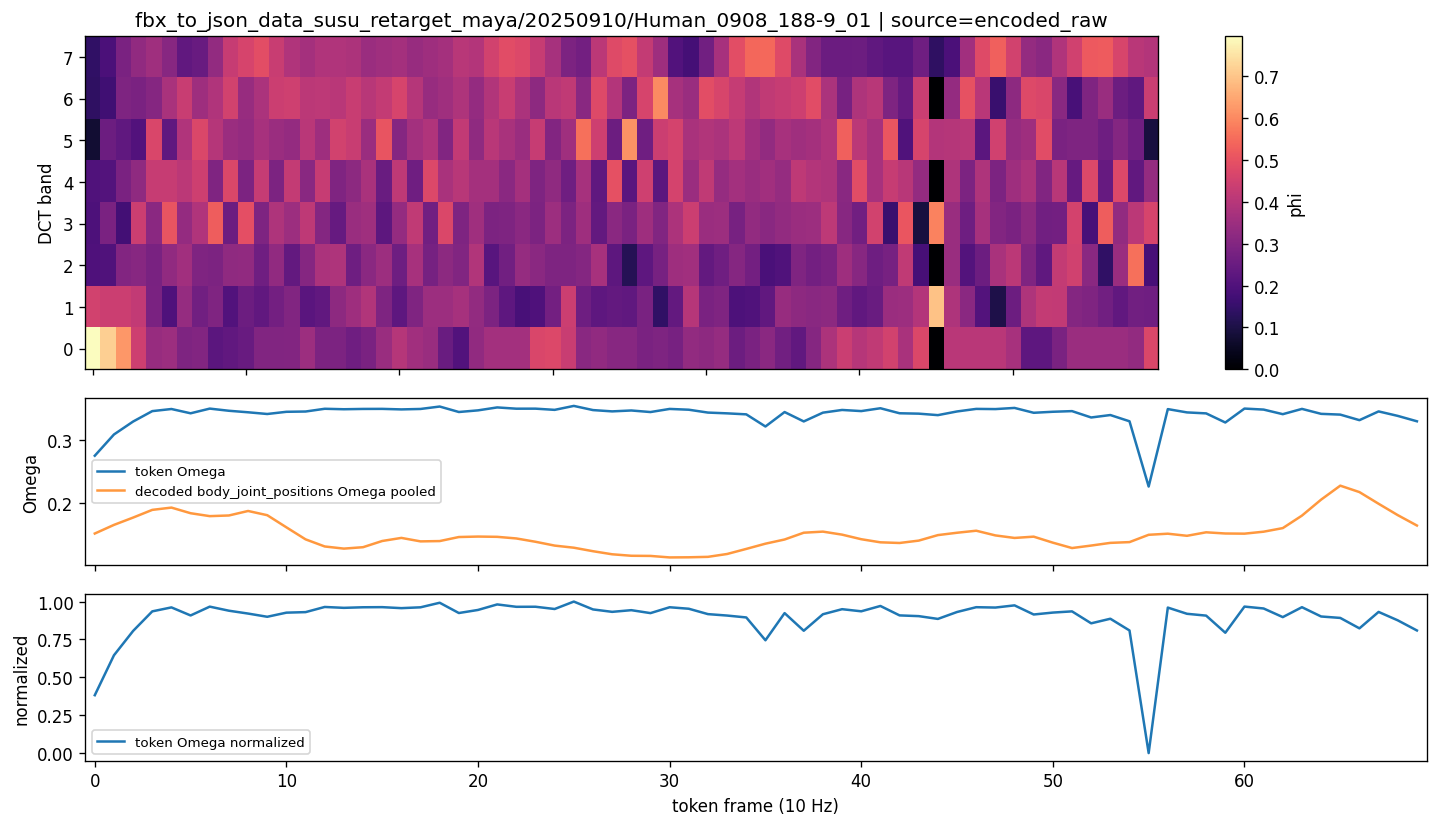

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250905__Human_0904_144-1_01.png


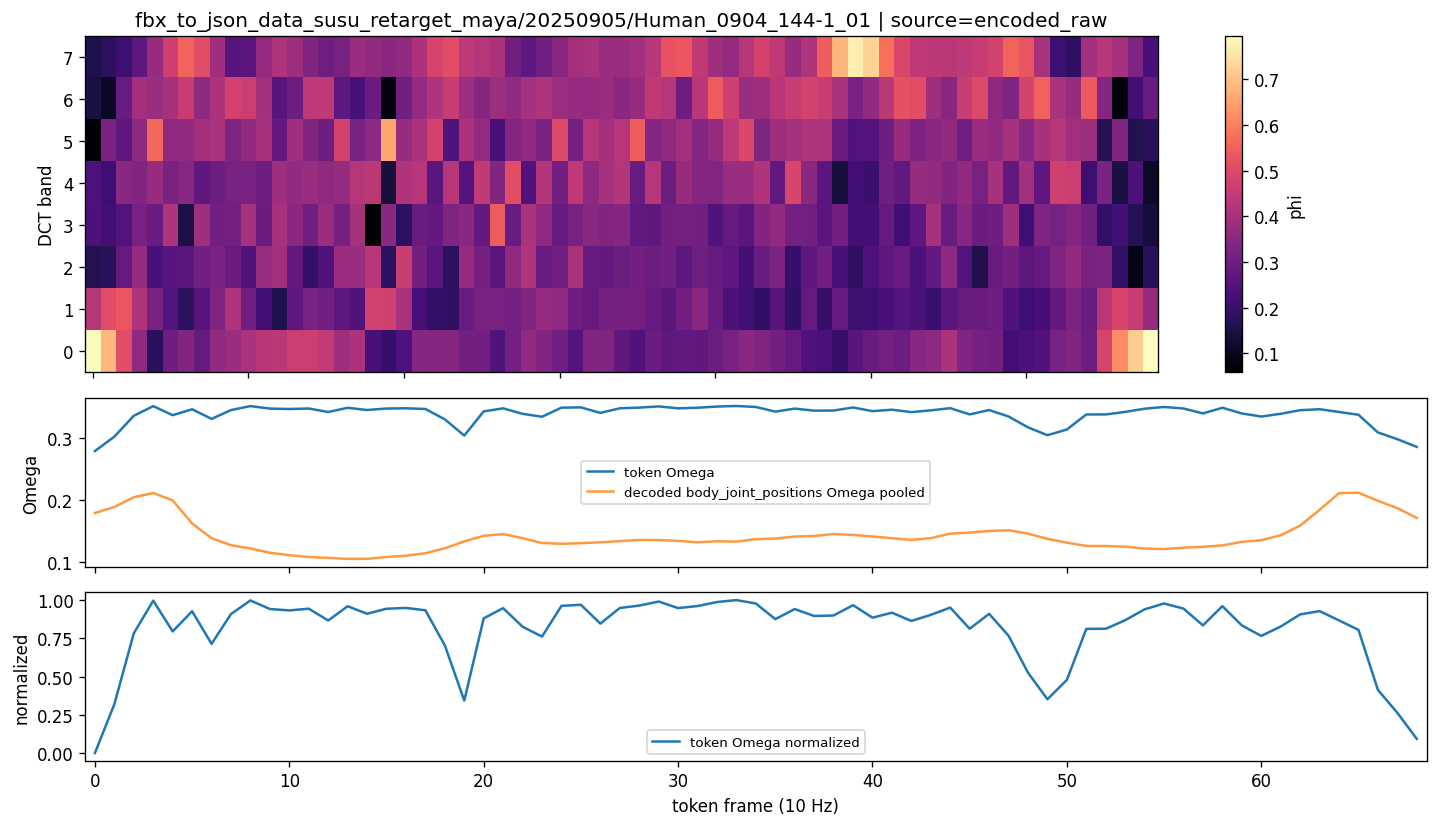

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20251015__Human_0916_250_3_8_01.png


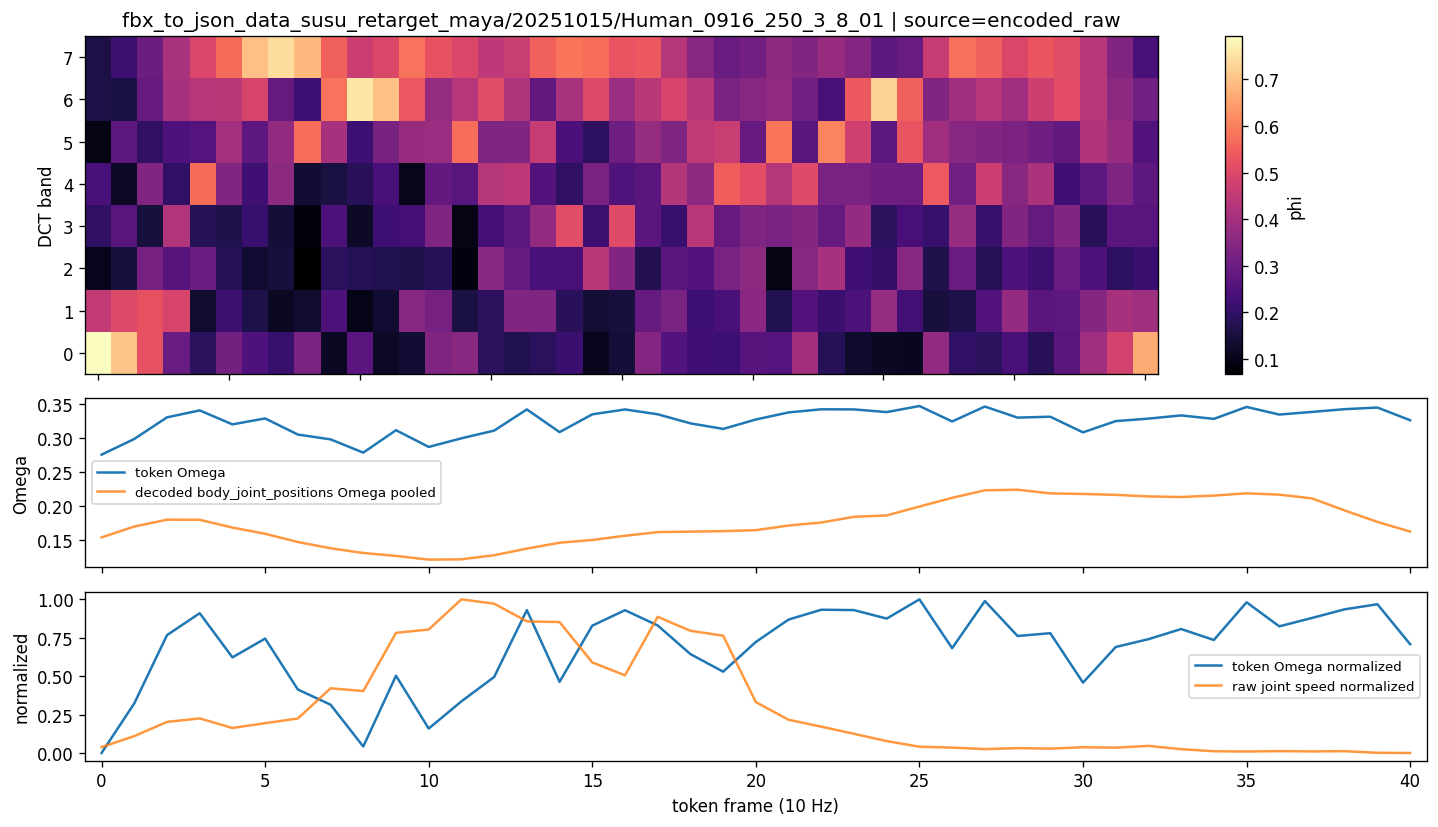

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250826__Human_0825_344-8_01.png


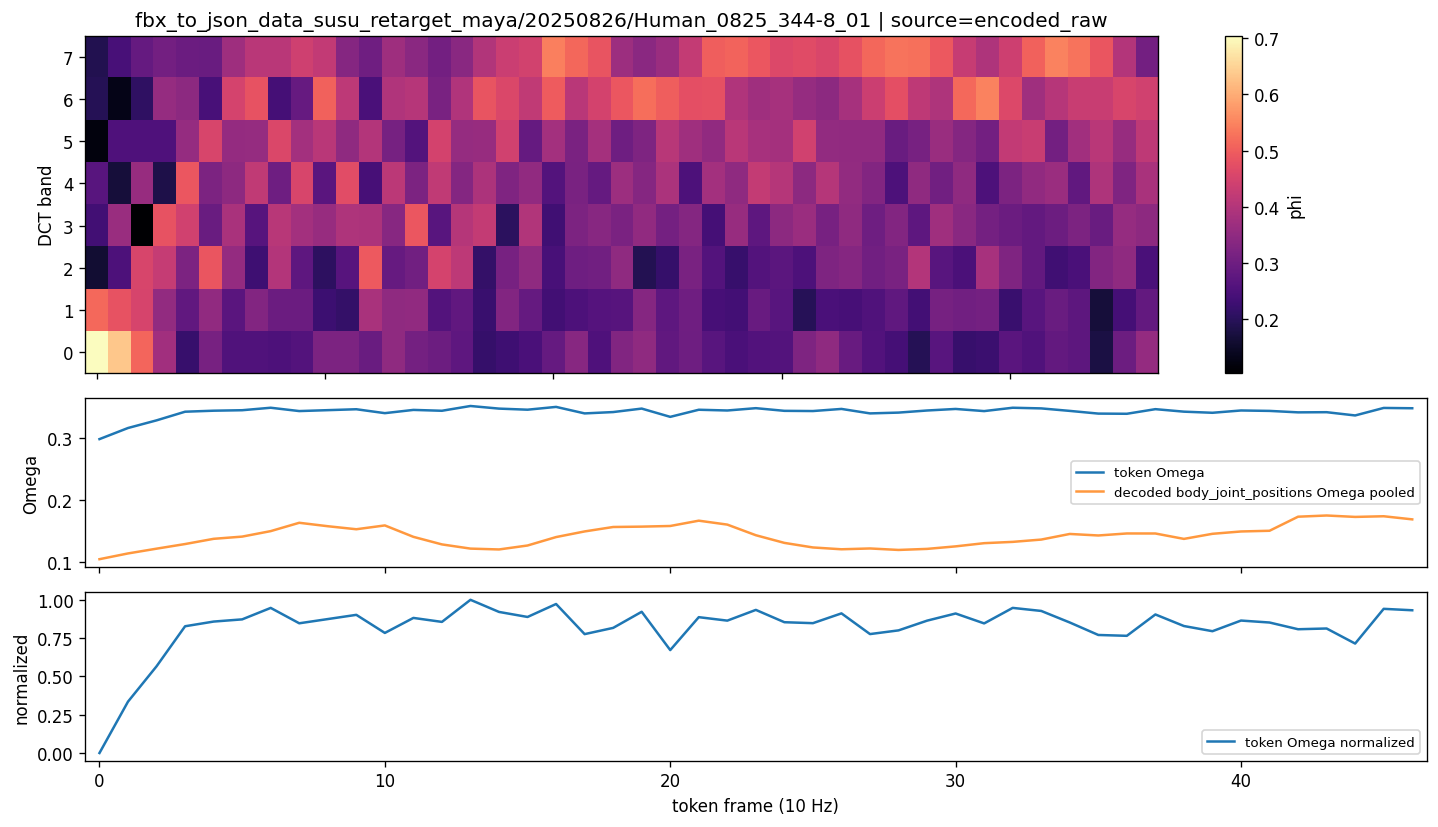

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250828__Human_0826_192-7_01.png


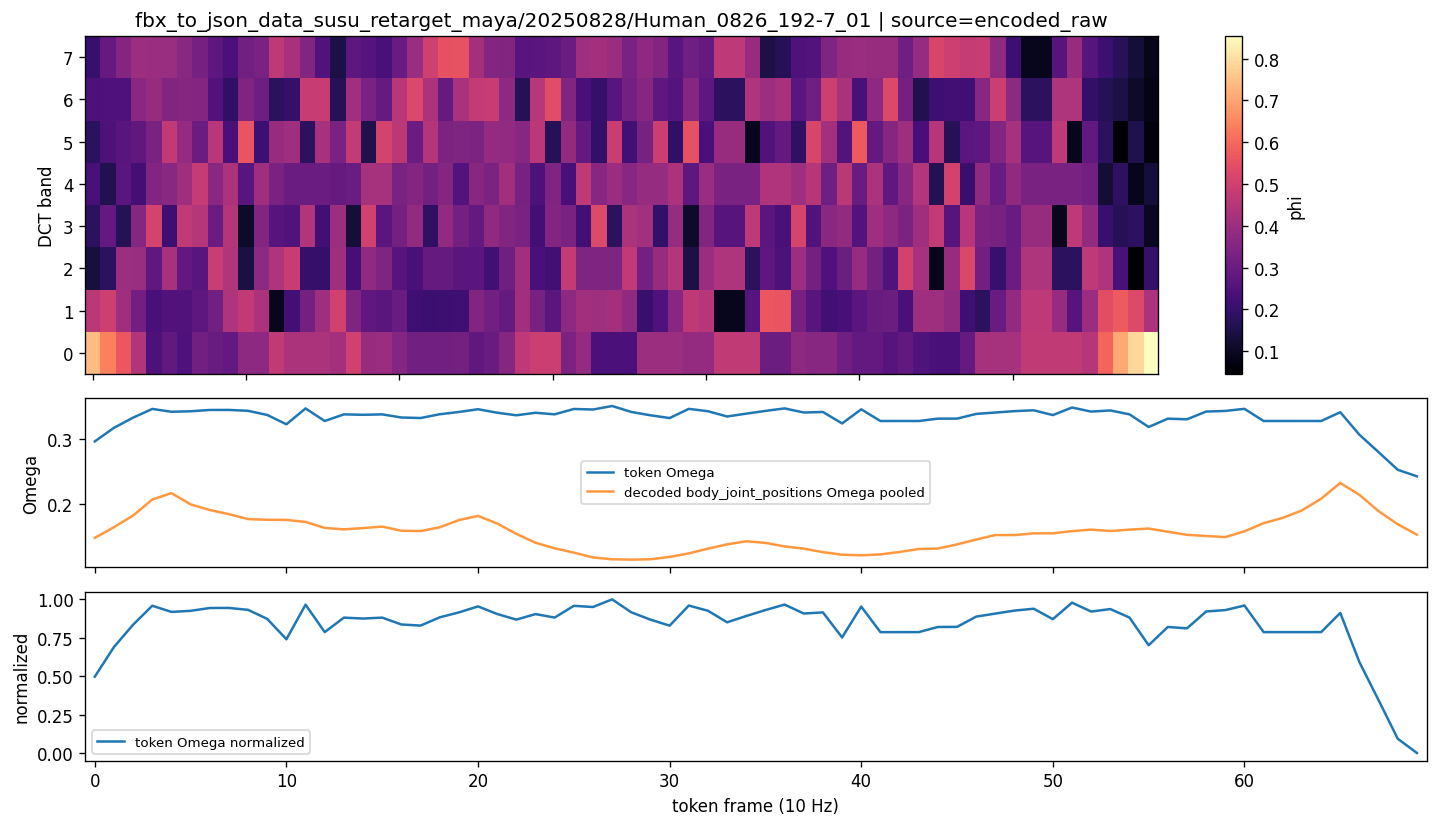

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250926__Human_0916_94_1_12_01.png


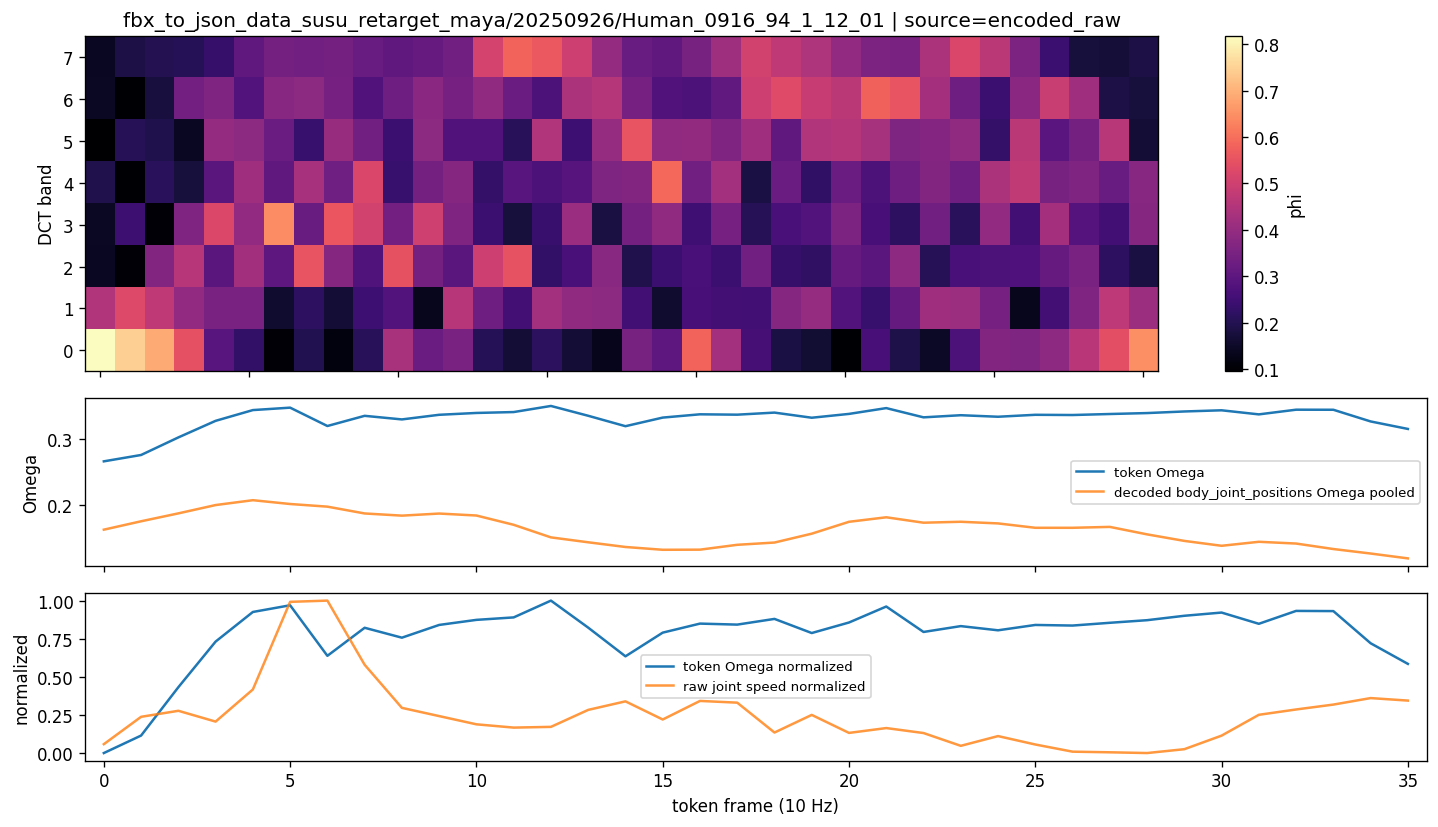

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250922__Human_0916_30_0_10_01.png


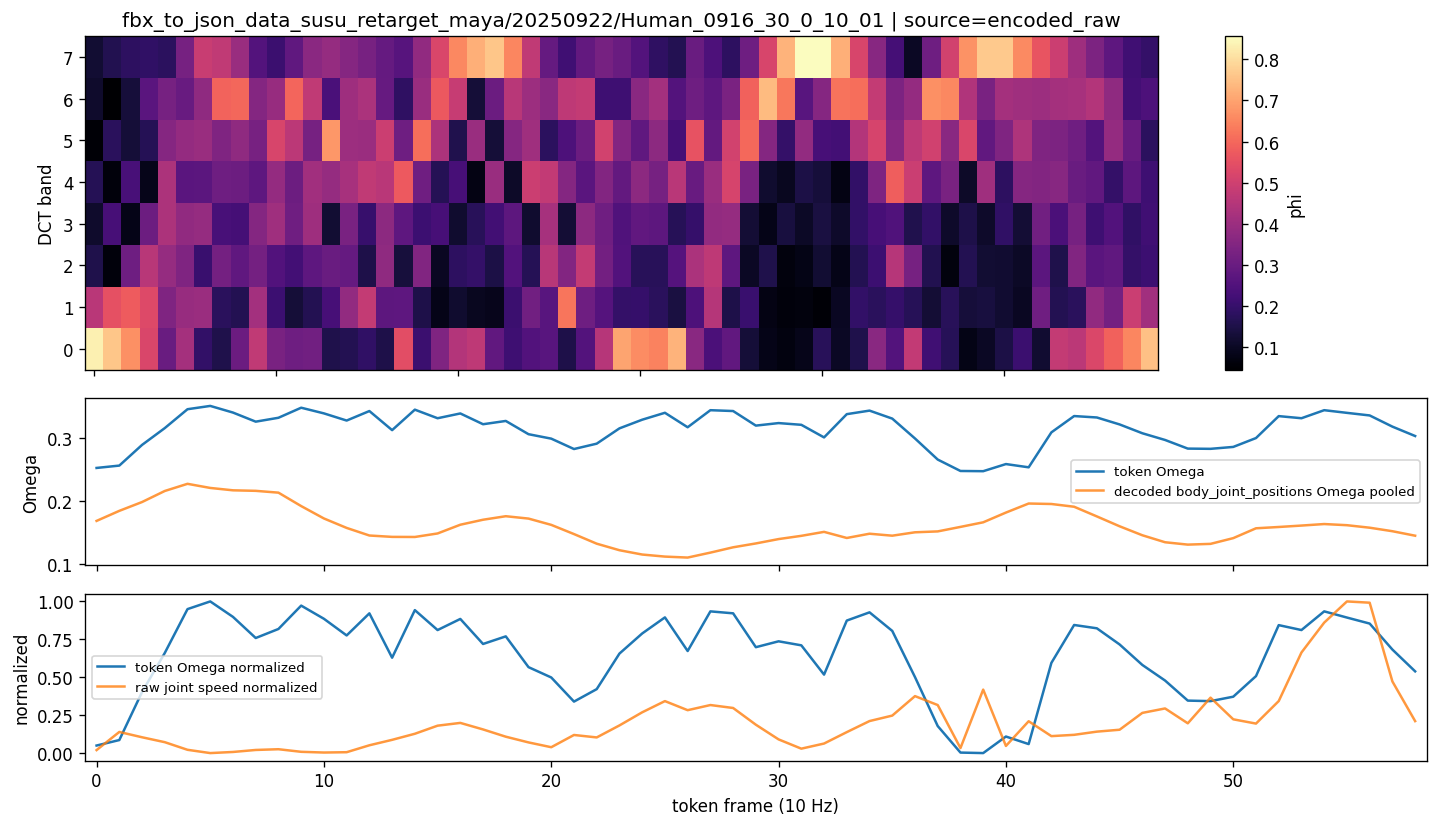

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20251031__Human_1021_92_2_8_01_XG.png


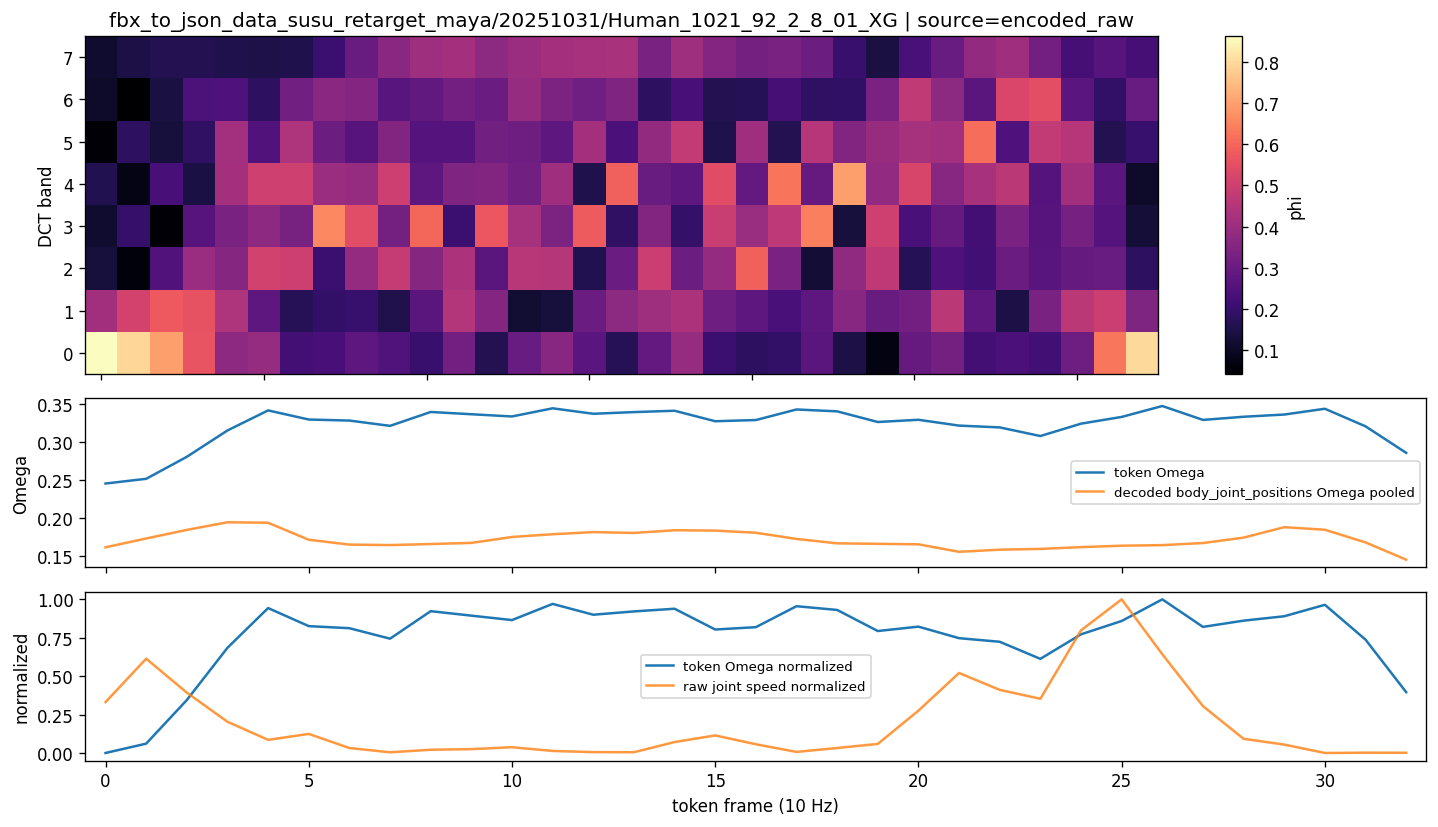

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20250805__Human_susu_250804_44-2_01.png


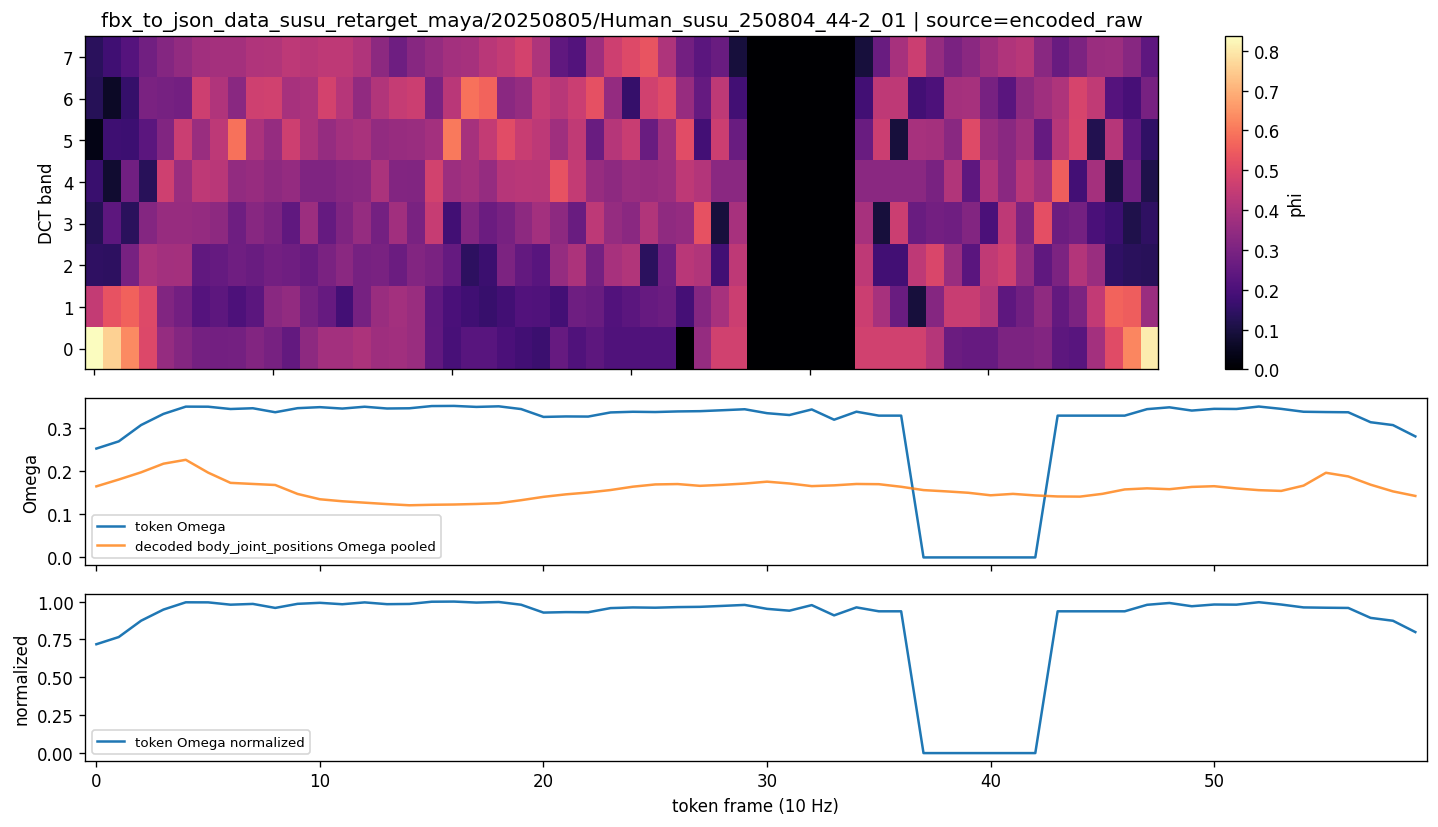

saved C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\verify_msd_susuinteracts\msd_visual_fbx_to_json_data_susu_retarget_maya__20251024__Human_0916_105_4_2_01_XG.png


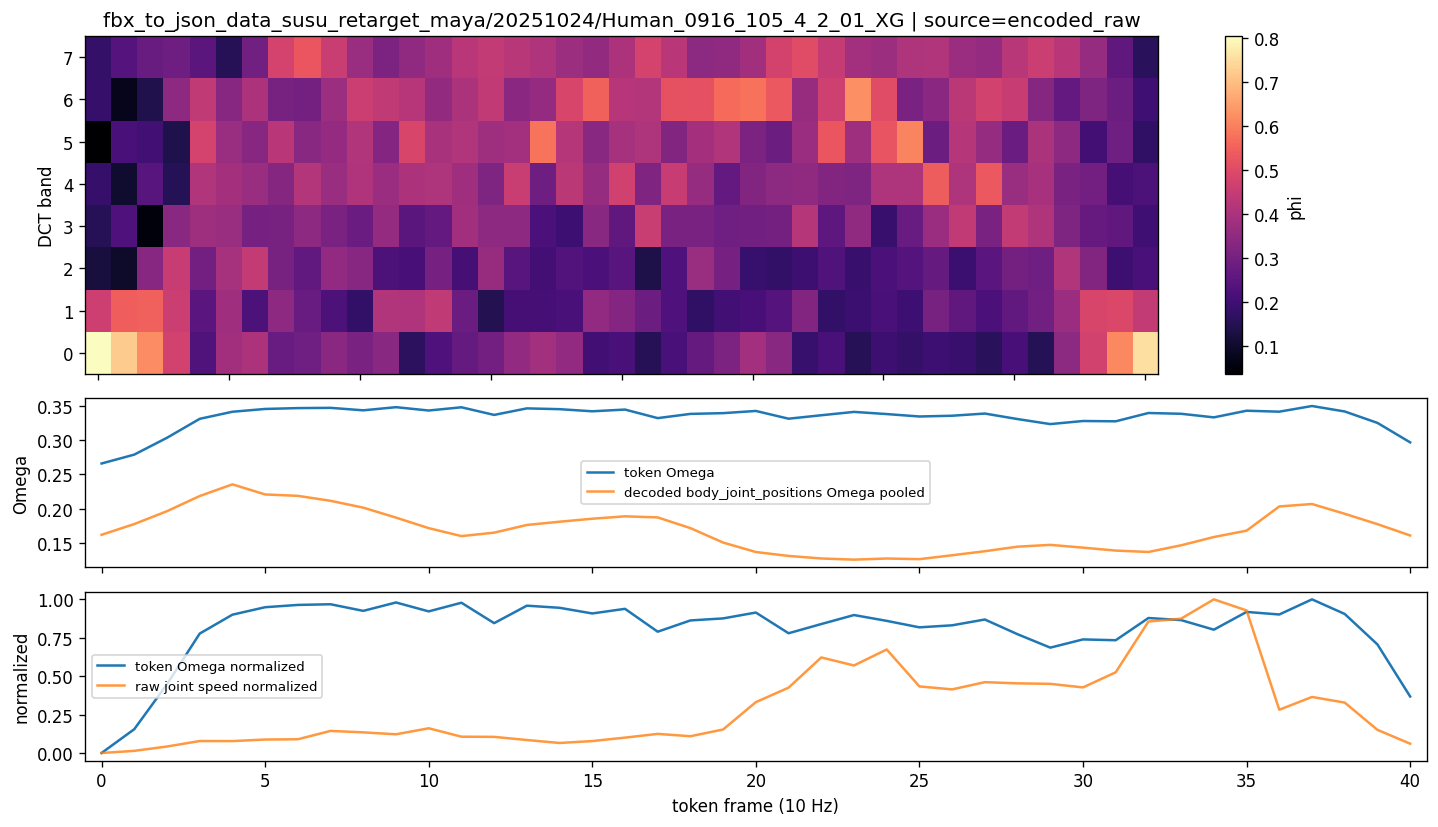

In [18]:
def pooled_raw_joint_speed(name, T_token):
    motion = load_motion_dict(name)
    pos = motion.get("positions")
    if pos is None:
        return None
    pos = np.asarray(pos, dtype=np.float32)
    vel = np.diff(pos, axis=0, prepend=pos[:1])
    speed = np.linalg.norm(vel, axis=-1).mean(axis=-1)
    L = (len(speed) // int(RVQVAE_UNIT_LENGTH)) * int(RVQVAE_UNIT_LENGTH)
    pooled = speed[:L].reshape(-1, int(RVQVAE_UNIT_LENGTH)).mean(axis=1)
    return pooled[:T_token]

def normalize_curve(y):
    y = np.asarray(y, dtype=np.float32)
    if y.size == 0 or float(y.max() - y.min()) < 1e-8:
        return np.zeros_like(y)
    return (y - y.min()) / (y.max() - y.min())

def plot_msd_clip(name, save=True):
    tokens, source = get_tokens(name)
    body_decoded = decode_tokens_to_body(tokens)
    motion_ref, ref_name = decoded_motion_reference_features(name, body_decoded)
    phi_tok, om_tok = msd_from_tokens(tokens, codebooks, MSDConfig(W=W_TOKEN))
    _, om_mot = msd_from_motion(motion_ref, MSDConfig(W=W_MOTION, energy_floor=0.0))
    om_mot_tok = pool_motion_omega_to_token_rate(om_mot.detach().cpu(), int(tokens.shape[0]))
    raw_speed = pooled_raw_joint_speed(name, int(tokens.shape[0]))

    phi_np = phi_tok.detach().cpu().numpy()
    om_tok_np = om_tok.detach().cpu().numpy()
    om_mot_np = om_mot_tok.detach().cpu().numpy()
    title_text = TEXT_MAP.get(name, "")[:120]  # kept for notebook inspection, not plotted (font portability)

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0, 1.0]})
    im = axes[0].imshow(phi_np.T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_ylabel("DCT band")
    axes[0].set_title(f"{name} | source={source}")
    fig.colorbar(im, ax=axes[0], label="phi")

    axes[1].plot(om_tok_np, label="token Omega")
    axes[1].plot(om_mot_np[: len(om_tok_np)], label=f"decoded {ref_name} Omega pooled", alpha=0.8)
    axes[1].set_ylabel("Omega")
    axes[1].legend(fontsize=8)

    axes[2].plot(normalize_curve(om_tok_np), label="token Omega normalized")
    if raw_speed is not None:
        axes[2].plot(normalize_curve(raw_speed), label="raw joint speed normalized", alpha=0.8)
    axes[2].set_xlabel(f"token frame ({TOKEN_FPS:g} Hz)")
    axes[2].set_ylabel("normalized")
    axes[2].legend(fontsize=8)
    fig.tight_layout()

    if save:
        safe = name.replace("/", "__").replace("\\", "__")
        out = OUTPUT_DIR / f"msd_visual_{safe}.png"
        fig.savefig(out, dpi=140, bbox_inches="tight")
        print("saved", out)
    return fig

visual_names = names_quick[:VISUAL_N]
for name in visual_names:
    plot_msd_clip(name, save=True)
    plt.show()

## 1.5 Precompute And Cache

This cell writes `phi`, `omega`, and per-clip z-scored/clipped loss weights to `.npz` files plus `manifest.json`. It defaults to a small cache. For the full train/val/test cache, set `RUN_FULL_CACHE=True`, `CACHE_SPEEDS=[0.9, 1.0, 1.1]` if that matches training, and preferably precompute `motion_token_data` first.

In [19]:
def cache_key(clip_id, speed):
    safe = clip_id.replace("/", "__").replace("\\", "__")
    return f"{safe}@speed{float(speed):.2f}"

def write_msd_cache(splits=("val",), speeds=(1.0,), limit_per_split=10, overwrite=False):
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    manifest = []
    if RUN_FULL_CACHE and not MOTION_TOKEN_DIR.exists():
        raise RuntimeError(
            "Full cache requested but motion_token_data is missing. Run preprocess_data.py --motion first, "
            "or keep RUN_FULL_CACHE=False for raw-encoding verification subsets."
        )
    for split in splits:
        names = valid_names(split, limit=None if RUN_FULL_CACHE else limit_per_split)
        for name in tqdm(names, desc=f"cache {split}"):
            tokens, source = get_tokens(name)
            for speed in speeds:
                toks = apply_speed_variant_tokens(tokens, speed)
                key = cache_key(name, speed)
                path = CACHE_DIR / f"{key}.npz"
                if path.exists() and not overwrite:
                    manifest.append({"key": key, "clip": name, "split": split, "speed": float(speed), "path": path.name, "source": source, "cached": True})
                    continue
                phi, omega = msd_from_tokens(toks, codebooks, MSDConfig(W=W_TOKEN))
                weights = omega_to_weights(omega, lo=0.5, hi=2.0)
                np.savez_compressed(
                    path,
                    phi=phi.detach().cpu().numpy().astype(np.float16),
                    omega=omega.detach().cpu().numpy().astype(np.float32),
                    weight=weights.detach().cpu().numpy().astype(np.float32),
                )
                manifest.append({
                    "key": key,
                    "clip": name,
                    "split": split,
                    "speed": float(speed),
                    "T": int(omega.shape[0]),
                    "path": path.name,
                    "source": source,
                    "cached": False,
                })
    manifest_path = CACHE_DIR / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print("cache entries:", len(manifest), "manifest:", manifest_path)
    return manifest

cache_splits = ("train", "val", "test") if RUN_FULL_CACHE else (SPLIT_FOR_QUICK_CHECKS,)
cache_limit = None if RUN_FULL_CACHE else CACHE_LIMIT_PER_SPLIT
manifest = write_msd_cache(cache_splits, CACHE_SPEEDS, limit_per_split=cache_limit, overwrite=False)
manifest[:2]

cache val: 100%|██████████| 10/10 [00:00<00:00, 56.92it/s]


cache entries: 10 manifest: C:\Users\WenJChai\Desktop\sentiAvatar-sandbox\motion_generation\utils\msd\outputs\cache_token_msd\manifest.json


[{'key': 'fbx_to_json_data_susu_retarget_maya__20250910__Human_0908_188-9_01@speed1.00',
  'clip': 'fbx_to_json_data_susu_retarget_maya/20250910/Human_0908_188-9_01',
  'split': 'val',
  'speed': 1.0,
  'path': 'fbx_to_json_data_susu_retarget_maya__20250910__Human_0908_188-9_01@speed1.00.npz',
  'source': 'encoded_raw',
  'cached': True},
 {'key': 'fbx_to_json_data_susu_retarget_maya__20250905__Human_0904_144-1_01@speed1.00',
  'clip': 'fbx_to_json_data_susu_retarget_maya/20250905/Human_0904_144-1_01',
  'split': 'val',
  'speed': 1.0,
  'path': 'fbx_to_json_data_susu_retarget_maya__20250905__Human_0904_144-1_01@speed1.00.npz',
  'source': 'encoded_raw',
  'cached': True}]

## Cache Hit Path Check

This simulates the dataloader side: load precomputed arrays by key and assert shapes. Training code should use this path rather than recomputing DCT inside `__getitem__` or the collator.

In [20]:
class MSDCache:
    def __init__(self, root):
        self.root = Path(root)
        with open(self.root / "manifest.json", "r", encoding="utf-8") as f:
            self.rows = json.load(f)
        self.by_key = {row["key"]: row for row in self.rows}

    def get(self, key):
        row = self.by_key[key]
        data = np.load(self.root / row["path"])
        return data["phi"], data["omega"], data["weight"], row

cache = MSDCache(CACHE_DIR)
for key in list(cache.by_key)[: min(5, len(cache.by_key))]:
    phi, omega, weight, row = cache.get(key)
    assert phi.shape[0] == omega.shape[0] == weight.shape[0]
    assert phi.shape[1] == W_TOKEN
    assert np.isfinite(phi).all() and np.isfinite(omega).all() and np.isfinite(weight).all()
    assert weight.min() >= 0.5 - 1e-6 and weight.max() <= 2.0 + 1e-6
print("cache hit check passed for", min(5, len(cache.by_key)), "entries")

cache hit check passed for 5 entries


## Decision Checklist

- Synthetic checks pass: the core DCT/MSD math is sane.
- Decoded-motion variant runs on 10 clips: the RVQVAE integration is sane.
- Agreement gate: if 500-clip median Spearman is above 0.9, use cheap token-level MSD. Otherwise precompute decoded-motion MSD.
- Visual sanity: inspect saved `msd_visual_*.png` under `outputs/verify_msd_susuinteracts`; high `Omega` should align with gesture strokes or raw joint-speed spikes.
- Cache: use `outputs/cache_token_msd/manifest.json` and `.npz` files in the dataloader; do not run DCT during training.